# Assignment 7
### Do any five.

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

In [1]:
import random
import numpy as np

# Set seed
random.seed(1)
np.random.seed(1)

def simulate_single_die(n=100000):
    """Simulate rolling a single die."""
    rolls = [random.randint(1, 6) for _ in range(n)]
    return np.mean(rolls)

def simulate_two_dice(n=100000):
    """Simulate rolling two dice and adding them."""
    totals = [random.randint(1, 6) + random.randint(1, 6) for _ in range(n)]
    return np.mean(totals)

def simulate_roulette(n=100000, bet_type='red'):
    """Simulate European roulette winnings (betting $1 each time)."""
    winnings = []
    for _ in range(n):
        spin = random.randint(0, 36)  # 0-36 (37 pockets)
        if bet_type == 'red':
            # Red numbers: 1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36
            red_nums = {1,3,5,7,9,12,14,16,18,19,21,23,25,27,30,32,34,36}
            winnings.append(1 if spin in red_nums else -1)
    return np.mean(winnings)

def simulate_reroll_on_six_once(n=100000):
    """Roll a die. If you get a 6, roll again and add. Otherwise just record."""
    totals = []
    for _ in range(n):
        first_roll = random.randint(1, 6)
        if first_roll == 6:
            second_roll = random.randint(1, 6)
            totals.append(first_roll + second_roll)
        else:
            totals.append(first_roll)
    return np.mean(totals)

def simulate_reroll_until_no_six(n=100000):
    """Roll a die. Keep rolling and adding while you get 6s."""
    totals = []
    for _ in range(n):
        total = 0
        while True:
            roll = random.randint(1, 6)
            total += roll
            if roll != 6:
                break
        totals.append(total)
    return np.mean(totals)

# Run simulations
print("EXPECTED VALUE SIMULATIONS")
print("=" * 60)

print("\n1. Single die roll:")
sim_result = simulate_single_die()
print(f"   Theoretical: 3.5")
print(f"   Simulated:   {sim_result:.4f}")

print("\n2. Two dice (sum):")
sim_result = simulate_two_dice()
print(f"   Theoretical: 7.0")
print(f"   Simulated:   {sim_result:.4f}")

print("\n3. European roulette (betting $1 on red):")
sim_result = simulate_roulette()
print(f"   Theoretical: -0.027 (-1/37)")
print(f"   Simulated:   {sim_result:.4f}")

print("\n4. Roll once, reroll on first six:")
sim_result = simulate_reroll_on_six_once()
theoretical = (5/6) * 3 + (1/6) * (6 + 3.5)
print(f"   Theoretical: {theoretical:.4f}")
print(f"   Simulated:   {sim_result:.4f}")

print("\n5. Keep rolling until no six:")
sim_result = simulate_reroll_until_no_six()
print(f"   Theoretical: 4.2")
print(f"   Simulated:   {sim_result:.4f}")

EXPECTED VALUE SIMULATIONS

1. Single die roll:
   Theoretical: 3.5
   Simulated:   3.4995

2. Two dice (sum):
   Theoretical: 7.0
   Simulated:   6.9922

3. European roulette (betting $1 on red):
   Theoretical: -0.027 (-1/37)
   Simulated:   -0.0215

4. Roll once, reroll on first six:
   Theoretical: 4.0833
   Simulated:   4.0953

5. Keep rolling until no six:
   Theoretical: 4.2
   Simulated:   4.2218


## 2. 
- Compute the expected value for a uniform random variable.
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

### Question 1: Expected Value of a Uniform Random Variable

When I think about a uniform random variable, I'm picturing a scenario where every value in a certain range is equally likely to occur. For example, if I'm looking at a uniform distribution between 2 and 8, any number between 2 and 8 has the same chance of showing up.

If every value is equally likely, the average should be right in the middle. This makes sense. If I'm equally likely to get any value between 2 and 8, on average I should expect to get 5, which is exactly halfway between them.

Mathematically, this works out to just taking the two endpoints and averaging them. So for a uniform distribution between 'a' and 'b', the expected value is simply "a plus b, divided by 2." That's it! The midpoint of the range is the expected value.

I can verify this makes sense by thinking about a uniform distribution between 0 and 1. The expected value would be 0.5, which is exactly in the middle. Or between 0 and 10, where the expected value would be 5. This pattern holds for any uniform distribution.

### Question 2: Showing that the Expected Value of "a plus b times X" equals "a plus b times the Expected Value of X"

This property is called linearity of expectation, and it's one of the most important ideas in probability. Let me walk through why this works.

When I have a random variable X and I want to find the expected value of "a plus b times X," I need to think about what expectation actually means. The expected value is essentially a weighted average: I'm taking all possible values, multiplying each by its probability, and adding them up.

So when I compute the expected value of "a plus b times X," I'm taking every possible outcome, applying this transformation (multiplying by b and adding a), then weighting by the probability of that outcome.

Here's where the magic happens: I can split this calculation into two parts. The "a" part is just a constant, so when I weight it by all the probabilities and add them up, I just get "a" back (since all the probabilities sum to 1). The "b times x" part, when I weight it by probabilities and add up, gives me "b times the expected value of X."

Put them together, and I get "a plus b times the expected value of X."

This is incredibly powerful because it means expectation is linear. If I want to know the expected value of something like "3 plus 2 times X," I don't need to recalculate everything from scratch. I can just take the expected value of X, multiply it by 2, and add 3. This works every single time, regardless of what the distribution of X looks like.

This also means that if I have two random variables and I want the expected value of their sum, it's just the sum of their expected values.

### Question 3: Why the Expected Value of a Transformed Variable Doesn't Equal the Transformation of the Expected Value

**Example with Uniform Distribution and Squaring:**

Let's take a uniform distribution between 0 and 1. The expected value is 0.5, as I established earlier in quesiton 1.

If I want the expected value of X-squared, I need to think about all the values between 0 and 1, square each one, and average them. When I work through the math, I get one-third (about 0.333).

But if I had just taken the expected value (0.5) and squared it, I'd get 0.25. Again, these are different! The expected value of X-squared is one-third, not one-quarter.

**Example with Square Root:**

Let's try a different function: square root. If I have an exponential distribution with an expected value of 1, and I want to know the expected value of the square root of X, I need to take the square root of every possible value and average them according to their probabilities.

When I do this calculation, I get something around 0.886. But if I had taken the square root of the expected value instead, I'd get the square root of 1, which is just 1. These don't match!

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


### Question 1: Variance of a Uniform Random Variable

For X, we know that $\mathbb{V}[X] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$.

We already know from earlier that:
$$\mathbb{E}[X] = \frac{a+b}{2}$$

**Find $\mathbb{E}[X^2]$**

$$\mathbb{E}[X^2] = \int_a^b x^2 \cdot \frac{1}{b-a} \, dx = \frac{1}{b-a} \int_a^b x^2 \, dx$$

$$= \frac{1}{b-a} \left[ \frac{x^3}{3} \right]_a^b = \frac{1}{b-a} \cdot \frac{b^3 - a^3}{3}$$

Using the factorization $b^3 - a^3 = (b-a)(b^2 + ab + a^2)$:

$$= \frac{1}{b-a} \cdot \frac{(b-a)(b^2 + ab + a^2)}{3} = \frac{b^2 + ab + a^2}{3}$$

**Put it all together to find the variance**

$$\mathbb{V}[X] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

$$= \frac{b^2 + ab + a^2}{3} - \left(\frac{a+b}{2}\right)^2$$

$$= \frac{b^2 + ab + a^2}{3} - \frac{(a+b)^2}{4}$$

$$= \frac{b^2 + ab + a^2}{3} - \frac{a^2 + 2ab + b^2}{4}$$

Finding a common denominator (12):

$$= \frac{4(b^2 + ab + a^2)}{12} - \frac{3(a^2 + 2ab + b^2)}{12}$$

$$= \frac{4b^2 + 4ab + 4a^2 - 3a^2 - 6ab - 3b^2}{12}$$

$$= \frac{b^2 - 2ab + a^2}{12} = \frac{(b-a)^2}{12}$$

**Result:** 
$$\boxed{\mathbb{V}[X] = \frac{(b-a)^2}{12}}$$

### Question 2: Proving Variance Formulas

#### Part A: Prove $\mathbb{V}[X] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$

**Proof:**

$$\mathbb{V}[X] = \mathbb{E}[(X - \mathbb{E}[X])^2]$$

Expand the square:
$$= \mathbb{E}[X^2 - 2X\mathbb{E}[X] + (\mathbb{E}[X])^2]$$

Apply linearity of expectation:
$$= \mathbb{E}[X^2] - \mathbb{E}[2X\mathbb{E}[X]] + \mathbb{E}[(\mathbb{E}[X])^2]$$

Note that $\mathbb{E}[X]$ is a constant, so:
$$= \mathbb{E}[X^2] - 2\mathbb{E}[X]\mathbb{E}[X] + (\mathbb{E}[X])^2$$

$$= \mathbb{E}[X^2] - 2(\mathbb{E}[X])^2 + (\mathbb{E}[X])^2$$

$$= \mathbb{E}[X^2] - (\mathbb{E}[X])^2$$

$$\boxed{\mathbb{V}[X] = \mathbb{E}[X^2] - (\mathbb{E}[X])^2}$$

### Part B: Prove $\mathbb{V}[a + bX] = b^2\mathbb{V}[X]$

**Proof:**

$$\mathbb{V}[a + bX] = \mathbb{E}[(a + bX - \mathbb{E}[a + bX])^2]$$

We know from linearity of expectation that $\mathbb{E}[a + bX] = a + b\mathbb{E}[X]$, so:
$$= \mathbb{E}[(a + bX - a - b\mathbb{E}[X])^2]$$

$$= \mathbb{E}[(bX - b\mathbb{E}[X])^2]$$

$$= \mathbb{E}[b^2(X - \mathbb{E}[X])^2]$$

Since $b^2$ is a constant:
$$= b^2 \mathbb{E}[(X - \mathbb{E}[X])^2]$$

$$= b^2 \mathbb{V}[X]$$

$$\boxed{\mathbb{V}[a + bX] = b^2\mathbb{V}[X]}$$

### Question 3: Linear Transformation of a Normal Random Variable

**Theorem:** If $X \sim N(\mu, \sigma^2)$, then $Y = a + bX \sim N(a + b\mu, b^2\sigma^2)$.

### Part A: Prove the mean is $a + b\mathbb{E}[X]$

**Proof:**

$$\mathbb{E}[Y] = \mathbb{E}[a + bX]$$

By linearity of expectation:
$$= a + b\mathbb{E}[X]$$

Since $\mathbb{E}[X] = \mu$:
$$= a + b\mu$$

$$\boxed{\mathbb{E}[a + bX] = a + b\mu}$$

### Part B: Prove the variance is $b^2\sigma_X^2$

**Proof:**

We already proved that $\mathbb{V}[a + bX] = b^2\mathbb{V}[X]$.

Since $\mathbb{V}[X] = \sigma^2$:
$$\mathbb{V}[a + bX] = b^2\sigma^2$$

$$\boxed{\mathbb{V}[a + bX] = b^2\sigma^2}$$

### Part C: Prove that $a + bX$ is normally distributed

The MGF of $X \sim N(\mu, \sigma^2)$ is:
$$M_X(t) = e^{\mu t + \frac{1}{2}\sigma^2 t^2}$$

For $Y = a + bX$, the MGF is:
$$M_Y(t) = \mathbb{E}[e^{tY}] = \mathbb{E}[e^{t(a+bX)}]$$

$$= \mathbb{E}[e^{ta} \cdot e^{tbX}]$$

$$= e^{ta} \mathbb{E}[e^{tbX}]$$

$$= e^{ta} M_X(bt)$$

Substituting the MGF of $X$:
$$= e^{ta} \cdot e^{\mu(bt) + \frac{1}{2}\sigma^2(bt)^2}$$

$$= e^{ta + b\mu t + \frac{1}{2}b^2\sigma^2 t^2}$$

$$= e^{(a + b\mu)t + \frac{1}{2}(b^2\sigma^2)t^2}$$

This is the MGF of a normal distribution with mean $(a + b\mu)$ and variance $(b^2\sigma^2)$.

Since the MGF uniquely determines the distribution:
$$\boxed{a + bX \sim N(a + b\mu, b^2\sigma^2)}$$

## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$
- The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

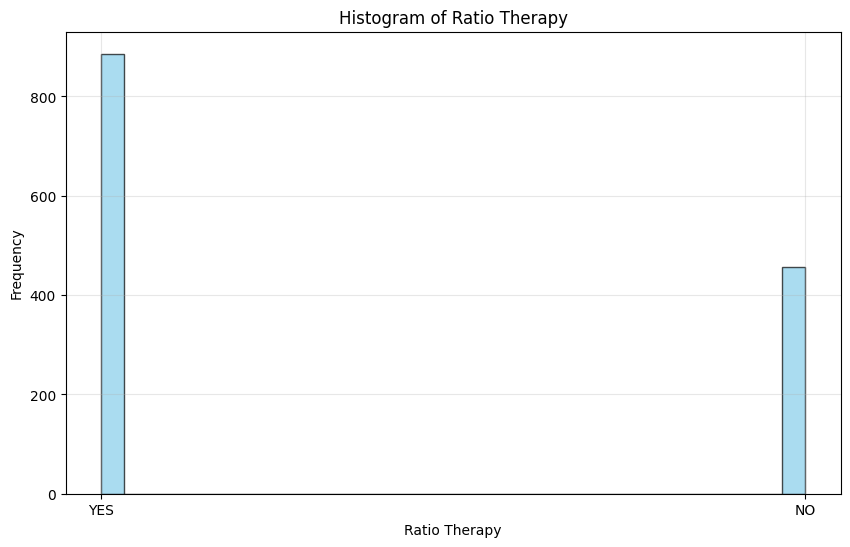

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

meta = pd.read_csv('/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Assignments/practice1/data/metabric.csv')

# 1. Histogram of 'Ratio Therapy'
plt.figure(figsize=(10, 6))
plt.hist(meta['Radio Therapy'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Histogram of Ratio Therapy')
plt.xlabel('Ratio Therapy')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [5]:
# 2. Likelihood function for binomial distribution

# Convert YES/NO to dummy variable (1 for YES, 0 for NO)
T = (meta['Radio Therapy'] == 'YES').astype(int)
print(f"\nTransformed treatment variable:")
print(T.value_counts())

n = len(T)
k = T.sum()  # number of patients receiving radiation therapy

print(f"Total patients (n): {n}")
print(f"Patients receiving radiation therapy (k): {k}")
print(f"Likelihood function: L(p) = p^{k} * (1-p)^{n-k}")


Transformed treatment variable:
Radio Therapy
1    886
0    457
Name: count, dtype: int64
Total patients (n): 1343
Patients receiving radiation therapy (k): 886
Likelihood function: L(p) = p^886 * (1-p)^457


MLE for p (p_hat): 0.6597


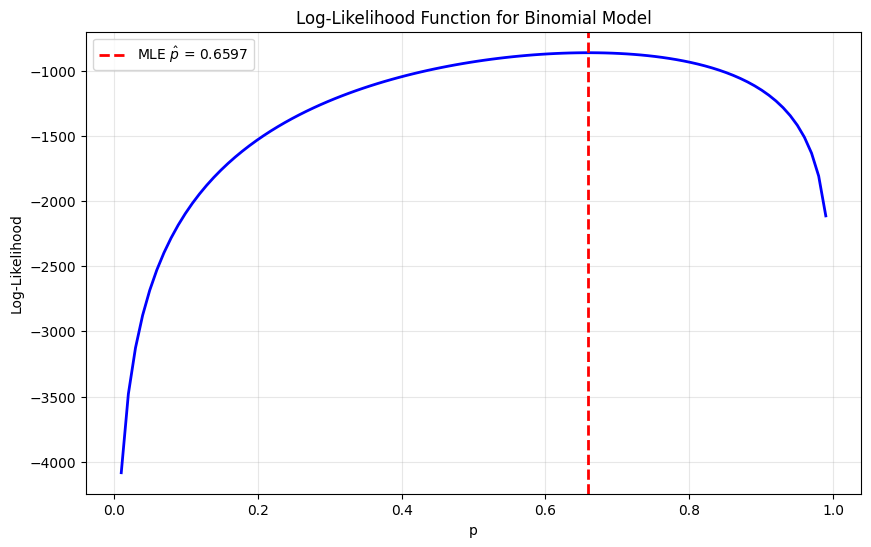

MLE via optimization: 0.6597
Are they equal? True


In [ ]:
# 3. Maximum Likelihood Estimation (MLE) for p
def log_likelihood(p, y):
    """Calculate log-likelihood for binomial distribution"""
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

# MLE for binomial is simply the sample mean
p_hat = T.mean()
print(f"MLE for p (p_hat): {p_hat:.4f}")

# Let's verify this maximizes the likelihood by testing different values
test_p_values = np.linspace(0.01, 0.99, 100)
log_likelihoods = [log_likelihood(p, T) for p in test_p_values]

plt.figure(figsize=(10, 6))
plt.plot(test_p_values, log_likelihoods, 'b-', linewidth=2)
plt.axvline(p_hat, color='red', linestyle='--', linewidth=2, 
            label=f'MLE $\hat{{p}}$ = {p_hat:.4f}')
plt.xlabel('p')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood Function for Binomial Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Verify using optimization
from scipy.optimize import minimize_scalar

def neg_log_likelihood(p, y):
    return -log_likelihood(p, y)

result = minimize_scalar(neg_log_likelihood, args=(T,), bounds=(0.001, 0.999), method='bounded')
p_hat_opt = result.x
print(f"MLE via optimization: {p_hat_opt:.4f}")

Performing bootstrap...


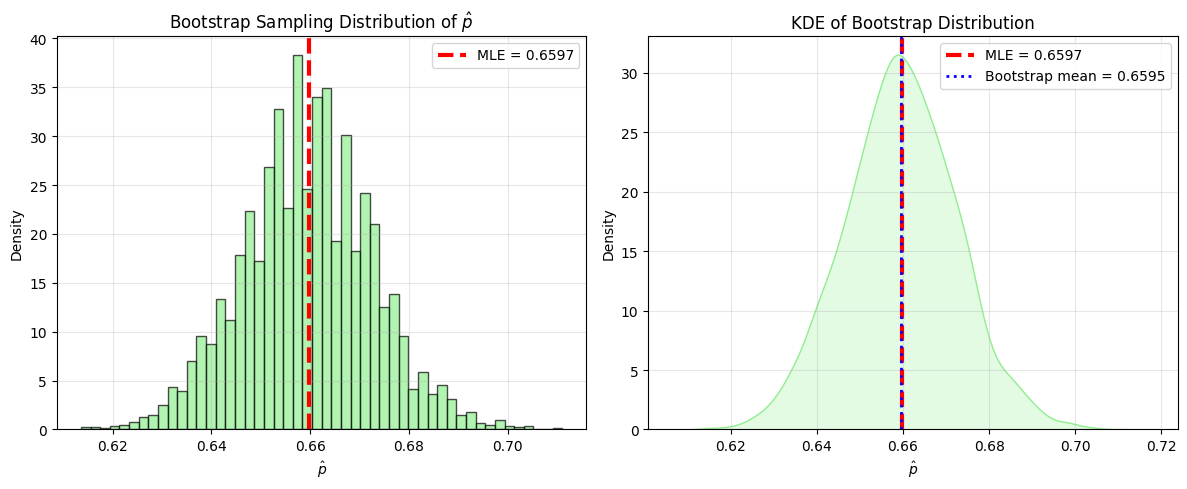

In [ ]:
# 4. Bootstrap the sampling distribution of p_hat
def bootstrap_estimator(data, n_bootstrap=5000):
    """Bootstrap sampling distribution of sample mean"""
    n = len(data)
    bootstrap_estimates = []
    
    for i in range(n_bootstrap):
        # Sample with replacement
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        # Calculate p_hat for this bootstrap sample
        p_bootstrap = bootstrap_sample.mean()
        bootstrap_estimates.append(p_bootstrap)
    
    return np.array(bootstrap_estimates)

# Perform bootstrap
bootstrap_estimates = bootstrap_estimator(T, n_bootstrap=5000)

# Plot bootstrap distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(bootstrap_estimates, bins=50, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.axvline(p_hat, color='red', linestyle='--', linewidth=3, label=f'MLE = {p_hat:.4f}')
plt.title('Bootstrap Sampling Distribution of $\hat{p}$')
plt.xlabel('$\hat{p}$')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.kdeplot(bootstrap_estimates, fill=True, color='lightgreen')
plt.axvline(p_hat, color='red', linestyle='--', linewidth=3, label=f'MLE = {p_hat:.4f}')
plt.axvline(np.mean(bootstrap_estimates), color='blue', linestyle=':', 
            linewidth=2, label=f'Bootstrap mean = {np.mean(bootstrap_estimates):.4f}')
plt.title('KDE of Bootstrap Distribution')
plt.xlabel('$\hat{p}$')
plt.ylabel('Density')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

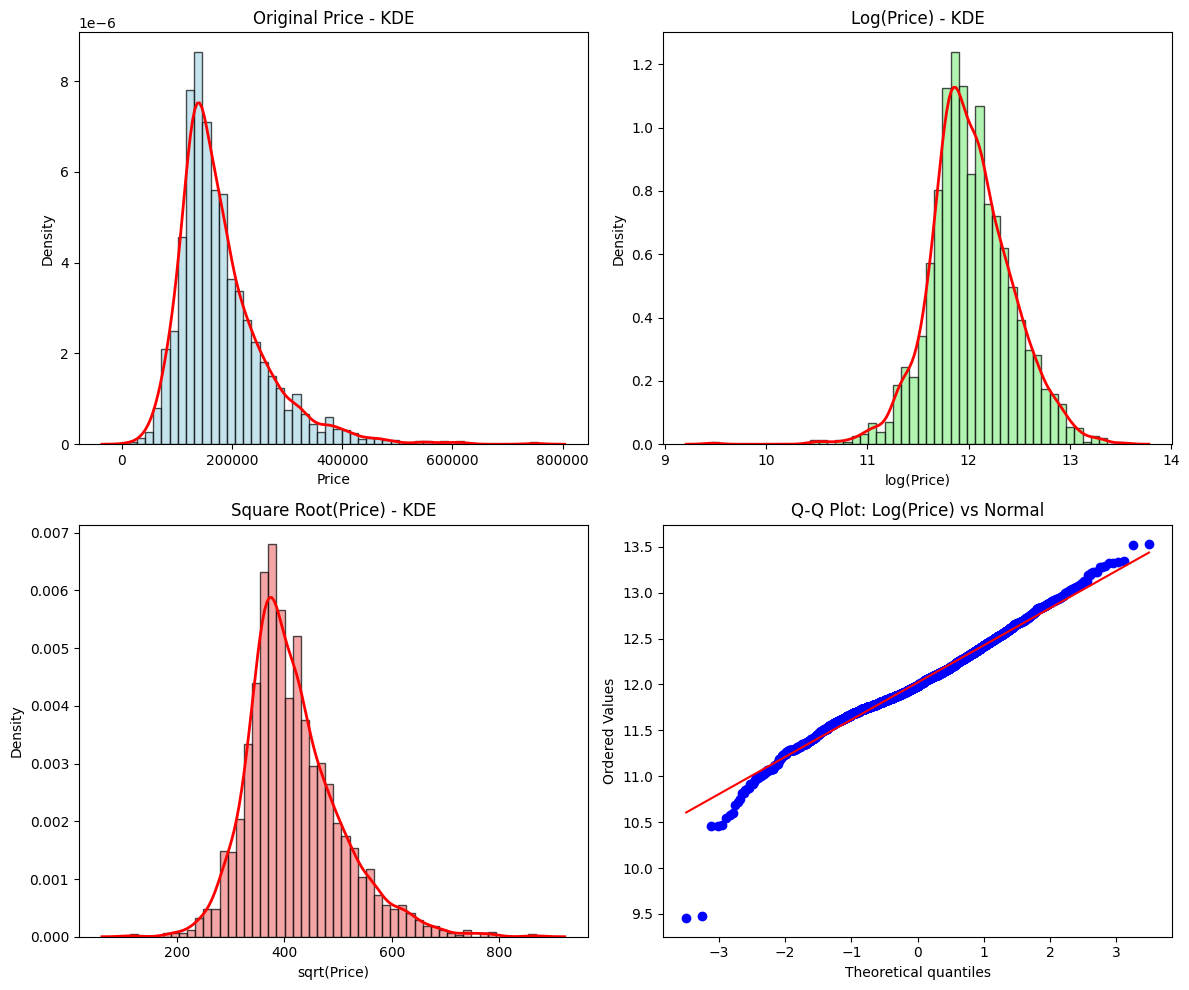

In [12]:
from scipy import stats
ames = pd.read_csv('/Users/adamchow/Library/CloudStorage/Box-Box/UVA/MSDS/Fall 2025/DS 5030/Assignments/practice1/data/ames_prices.csv')

# 1. KDE of price and exploration of transformations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original price
axes[0,0].hist(ames['price'], bins=50, alpha=0.7, density=True, color='lightblue', edgecolor='black')
sns.kdeplot(ames['price'], ax=axes[0,0], color='red', linewidth=2)
axes[0,0].set_title('Original Price - KDE')
axes[0,0].set_xlabel('Price')
axes[0,0].set_ylabel('Density')

# Log transformation
log_price = np.log(ames['price'])
axes[0,1].hist(log_price, bins=50, alpha=0.7, density=True, color='lightgreen', edgecolor='black')
sns.kdeplot(log_price, ax=axes[0,1], color='red', linewidth=2)
axes[0,1].set_title('Log(Price) - KDE')
axes[0,1].set_xlabel('log(Price)')
axes[0,1].set_ylabel('Density')

# Square root transformation
sqrt_price = np.sqrt(ames['price'])
axes[1,0].hist(sqrt_price, bins=50, alpha=0.7, density=True, color='lightcoral', edgecolor='black')
sns.kdeplot(sqrt_price, ax=axes[1,0], color='red', linewidth=2)
axes[1,0].set_title('Square Root(Price) - KDE')
axes[1,0].set_xlabel('sqrt(Price)')
axes[1,0].set_ylabel('Density')

# QQ plot for log(price)
axes[1,1].remove()
ax_qq = fig.add_subplot(2, 2, 4)
stats.probplot(log_price, dist="norm", plot=ax_qq)
ax_qq.set_title('Q-Q Plot: Log(Price) vs Normal')

plt.tight_layout()
plt.show()

In [15]:
# For a log-normal distribution:
# If Y = log(price) ~ N(μ, σ²), then price ~ LogNormal(μ, σ²)]

# 3. Likelihood function for log-normal distribution
from scipy.optimize import minimize

def log_likelihood_lognormal(params, prices):
    """
    Log-likelihood for log-normal distribution
    params = [mu, sigma]
    """
    mu, sigma = params
    n = len(prices)
    log_prices = np.log(prices)
    
    if sigma <= 0:
        return -np.inf
    
    ll = -n/2 * np.log(2 * np.pi) - n * np.log(sigma) - np.sum(log_prices) - 1/(2 * sigma**2) * np.sum((log_prices - mu)**2)
    return ll

def neg_log_likelihood(params, prices):
    return -log_likelihood_lognormal(params, prices)

log_prices = np.log(ames['price'])
mu_mle = np.mean(log_prices)
sigma_mle = np.sqrt(np.mean((log_prices - mu_mle)**2))

print("MLE Estimates:")
print(f"μ_hat = {mu_mle:.4f}")
print(f"σ_hat = {sigma_mle:.4f}")

# Verify with optimization
initial_guess = [np.mean(log_prices), np.std(log_prices)]
result = minimize(neg_log_likelihood, initial_guess, args=(ames['price'],), 
                  method='L-BFGS-B', bounds=[(None, None), (1e-6, None)])

mu_opt, sigma_opt = result.x
print(f"\nOptimization verification:")
print(f"μ_opt = {mu_opt:.4f}")
print(f"σ_opt = {sigma_opt:.4f}")

MLE Estimates:
μ_hat = 12.0210
σ_hat = 0.4075

Optimization verification:
μ_opt = 12.0210
σ_opt = 0.4075


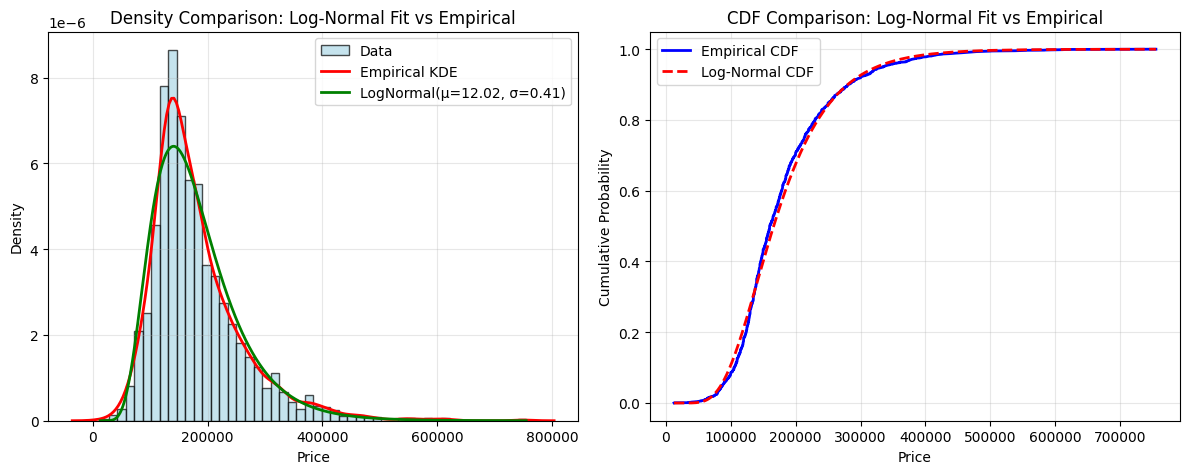

In [16]:
# 5. Plot fitted model vs empirical distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KDE comparison
x_range = np.linspace(ames['price'].min(), ames['price'].max(), 1000)

# Log-normal PDF with MLE parameters
lognorm_pdf = stats.lognorm.pdf(x_range, s=sigma_mle, scale=np.exp(mu_mle))

axes[0].hist(ames['price'], bins=50, density=True, alpha=0.7, color='lightblue', edgecolor='black', label='Data')
sns.kdeplot(ames['price'], ax=axes[0], color='red', linewidth=2, label='Empirical KDE')
axes[0].plot(x_range, lognorm_pdf, 'g-', linewidth=2, label=f'LogNormal(μ={mu_mle:.2f}, σ={sigma_mle:.2f})')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Density')
axes[0].set_title('Density Comparison: Log-Normal Fit vs Empirical')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ECDF comparison
def ecdf(data):
    """Compute ECDF"""
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

data_ecdf_x, data_ecdf_y = ecdf(ames['price'])
lognorm_cdf = stats.lognorm.cdf(data_ecdf_x, s=sigma_mle, scale=np.exp(mu_mle))

axes[1].plot(data_ecdf_x, data_ecdf_y, 'b-', linewidth=2, label='Empirical CDF')
axes[1].plot(data_ecdf_x, lognorm_cdf, 'r--', linewidth=2, label='Log-Normal CDF')
axes[1].set_xlabel('Price')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_title('CDF Comparison: Log-Normal Fit vs Empirical')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Overall, the fit discrepancy between Empirical KDE and the log-normal fit is pretty similar. The main difference between the two is the peak mismatch: The log-normal distribution peaks at a different location than the empirical data. The mode of the fitted log-normal appears to be left of the empirical mode. This discrepancy signifies to us that the most common house price is not well-represented in the data. 

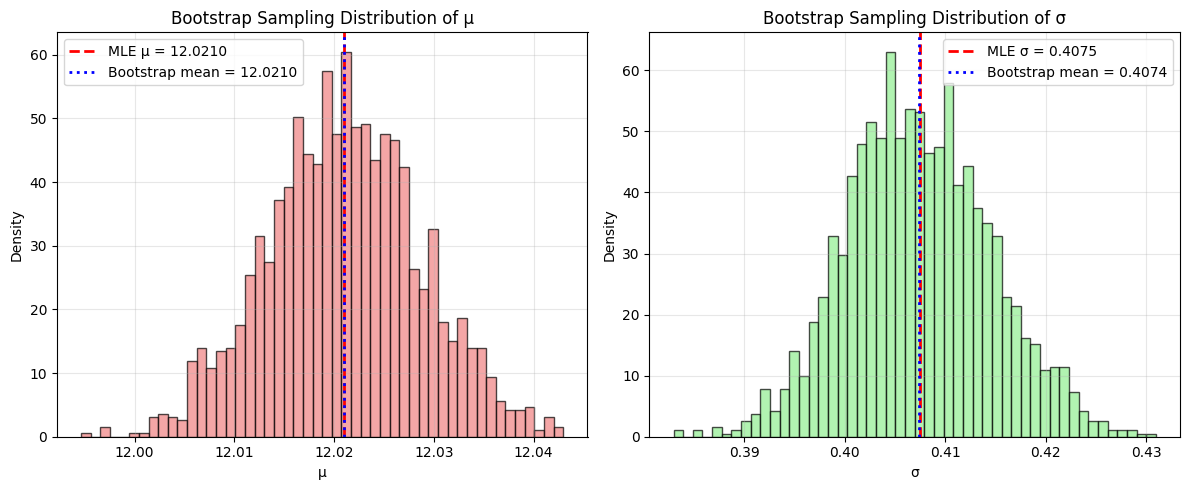

In [17]:
# 6. Bootstrap the sampling distribution of parameters
def bootstrap_lognormal_params(data, n_bootstrap=1000):
    n = len(data)
    bootstrap_mu = []
    bootstrap_sigma = []
    
    for i in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        # Calculate MLEs for this bootstrap sample
        log_sample = np.log(bootstrap_sample)
        mu_boot = np.mean(log_sample)
        sigma_boot = np.sqrt(np.mean((log_sample - mu_boot)**2))
        
        bootstrap_mu.append(mu_boot)
        bootstrap_sigma.append(sigma_boot)
    
    return np.array(bootstrap_mu), np.array(bootstrap_sigma)

bootstrap_mu, bootstrap_sigma = bootstrap_lognormal_params(ames['price'], n_bootstrap=2000)

# Plot bootstrap distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Mu distribution
axes[0].hist(bootstrap_mu, bins=50, alpha=0.7, color='lightcoral', edgecolor='black', density=True)
axes[0].axvline(mu_mle, color='red', linestyle='--', linewidth=2, label=f'MLE μ = {mu_mle:.4f}')
axes[0].axvline(np.mean(bootstrap_mu), color='blue', linestyle=':', linewidth=2, 
                label=f'Bootstrap mean = {np.mean(bootstrap_mu):.4f}')
axes[0].set_xlabel('μ')
axes[0].set_ylabel('Density')
axes[0].set_title('Bootstrap Sampling Distribution of μ')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sigma distribution
axes[1].hist(bootstrap_sigma, bins=50, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
axes[1].axvline(sigma_mle, color='red', linestyle='--', linewidth=2, label=f'MLE σ = {sigma_mle:.4f}')
axes[1].axvline(np.mean(bootstrap_sigma), color='blue', linestyle=':', linewidth=2, 
                label=f'Bootstrap mean = {np.mean(bootstrap_sigma):.4f}')
axes[1].set_xlabel('σ')
axes[1].set_ylabel('Density')
axes[1].set_title('Bootstrap Sampling Distribution of σ')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.